#**Modulo 37 - PCA**
**Aula 3: Aplicando com Python**

Nessa aula aplicaremos o PCA afim de reduzir a dimensionalidade dos nossos dados e a base que testaremos é a base que utilizamos no módulo passado de duelo.

 A base contém 2126 registros extraídos de exames de Cardiotocograma (CTG), que são essenciais para avaliar a saúde fetal. Esses exames foram classificados em três categorias: Normal, Suspeito e Patológico.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
base = pd.read_csv('fetal_health.csv')

In [3]:
base

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


No PCA (Análise de Componentes Principais), você aplica a transformação apenas nas variáveis preditoras (as variáveis explicativas ou X). O objetivo do PCA é reduzir a dimensionalidade dos dados, mantendo o máximo de variabilidade possível nas componentes principais.

In [4]:
X = base.drop(columns=['fetal_health'])

# Vamos relembrar PCA:

As componentes principais (ou PCs) no PCA são combinações lineares das variáveis originais que capturam a maior parte da variabilidade dos dados. Em vez de olhar para cada variável individualmente, o PCA cria novas "variáveis" (as componentes) que representam os dados de forma mais compacta, concentrando o máximo de informação possível em menos dimensões. As primeiras componentes explicam a maior parte da variação nos dados, permitindo que você trabalhe com menos variáveis sem perder muita informação.

Nessa base temos 21 variáveis, vamos tentar reduzir para 10.

Em geral, o objetivo do PCA é reduzir a dimensionalidade ao mesmo tempo em que se preserva a maior parte possível da informação (variabilidade) original.

In [5]:
pca = PCA(n_components= 10 ) # Substitua pelo número de componentes que deseja
# Ajustando o PCA aos dados X
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [6]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

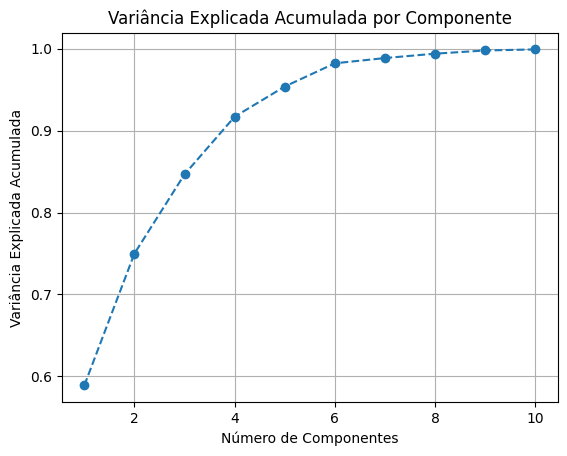

In [7]:
# Plotando a variância explicada acumulada
plt.plot(range(1, 11), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()


**Interpretando esse gráfico:**

Eixo X (Número de Componentes): Representa o número de componentes principais que estamos considerando, de 1 até o número de componentes que especificamos (neste caso, 10).

Eixo Y (Variância Explicada Acumulada): Representa a proporção acumulada da variância total dos dados que é explicada pelas componentes principais.

Curva: A curva mostra como a variância explicada se acumula conforme você adiciona mais componentes principais.

bserve o "Joelho" da Curva: O "joelho" (ou cotovelo) da curva é o ponto onde a adição de mais componentes não resulta em um aumento significativo da variância explicada. Esse ponto é uma boa indicação de quantas componentes principais são suficientes. Nosso "joelho" ocorre antes da 10ª componente, então podemos considerar menos componentes.

Com apenas 4 componentes, estamos conseguindo capturar 90% da variabilidade dos  dados originais. Isso significa que a maioria da informação relevante nos  dados pode ser representada por essas 4 componentes.

In [8]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.58898951 0.16092694 0.09669447 0.07033572 0.03682141 0.02837084
 0.00640861 0.00534764 0.00389701 0.00129613]
[2513.26961643 1313.71052286 1018.32434732  868.50689545  628.39906528
  551.59639911  262.16046536  239.47841767  204.43303284  117.89906024]


Nosso primeiro array mostra a proporção da variância total dos dados que é explicada por cada uma das componentes principais.

O segundo array contém os valores singulares associados a cada componente principal, que seriam a magnitude da variância explicada por cada componente.
Meio que indicam a "força" da componente no nosso modelo.

Vamos avaliar juntos a primeira componente:

Primeira Componente (0.5889): A primeira componente principal captura aproximadamente 58,9% da variância total dos dados. Isso significa que quase 60% da informação original está concentrada nessa única componente.


Primeira Componente (2513.27): Este valor singular elevado reflete a grande quantidade de variância capturada pela primeira componente.


**Vamos agora refazer nosso PCA com apenas 4 componentes:**

In [9]:
pca_4 = PCA(n_components= 4 )
pca_4.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [10]:
explained_variance = pca_4.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

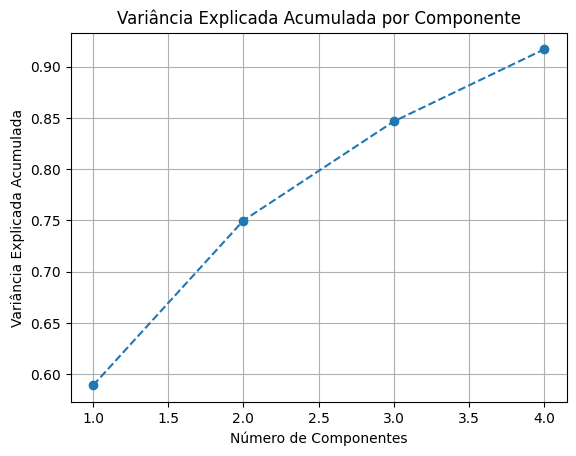

In [11]:
plt.plot(range(1, 5), cumulative_variance, marker='o', linestyle='--') ##ALTERAR O RANGE
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

# Contrução do modelo aplicando PCA:

In [12]:
Y = base['fetal_health']

In [13]:
X_pca = pca.fit_transform(X)

In [14]:
X_pca

array([[ 2.09355875e+01, -4.46359666e+01,  4.42632927e+01, ...,
        -1.74898513e+01, -1.33251804e+01, -9.92261592e+00],
       [ 6.18205499e+01,  3.03286707e+01, -2.98880467e+01, ...,
         3.48510523e+00, -1.32675300e-01, -2.69024440e-01],
       [ 6.25581101e+01,  2.91362827e+01, -2.95872141e+01, ...,
         3.12835798e+00,  2.81959718e+00, -1.28175753e+00],
       ...,
       [-2.15768651e+01,  2.67054022e+01,  5.22313027e+00, ...,
        -3.28487276e+00,  4.09162156e-03, -8.58893020e-02],
       [-2.31941746e+01,  2.47358012e+01,  6.67931316e+00, ...,
        -3.38978224e+00,  8.25739810e-01,  1.16219485e-01],
       [-4.95509848e+01,  8.41590488e+00,  1.28126666e+01, ...,
         7.29034286e-01, -3.41300569e-02, -1.19228019e+00]],
      shape=(2126, 10))

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X_pca, Y, test_size=0.3, random_state=42)

In [16]:
rf_model = RandomForestClassifier(random_state=42)

In [17]:
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
Y_pred = rf_model.predict(X_test)
print(f'{X_test}:{Y_pred}')

[[-3.90690752e+00  1.62566174e+00 -1.10098348e+01 ... -2.77068633e+00
   5.08170905e+00  1.59447609e-01]
 [ 1.83660554e+01 -3.37887315e+01 -2.30667110e+00 ...  3.76767510e+00
   9.14380797e-02  4.08015976e-02]
 [ 2.55760790e+01 -4.20189095e+00 -4.04808316e+00 ...  3.57338709e+00
  -2.83864627e+00 -1.54957391e+00]
 ...
 [-9.93368682e+01  2.89311583e+01  3.10817253e+01 ...  1.70865627e+00
  -6.10636278e-01  1.62287424e+00]
 [ 2.37058666e+01 -2.24054675e+01 -3.16212812e+01 ... -3.49470362e+00
  -5.71477195e-01 -1.03604930e-01]
 [ 5.44457580e+01  3.95106809e+01 -2.85700231e+01 ... -4.21769679e+00
   5.74862066e+00  1.12613523e+00]]:[1. 1. 1. 1. 1. 3. 1. 3. 2. 2. 1. 3. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 3. 1.
 1. 3. 3. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 3. 2. 1. 1. 2. 1. 1. 1. 2. 1. 2.
 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1.
 1. 1. 1. 2. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1.
 1. 3. 2. 1. 2. 1. 1. 2. 1. 2. 1. 1. 3. 1. 2. 1. 1. 2. 1. 3. 1. 1. 1. 1.

In [19]:
print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred))

print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred))

Matriz de Confusão:
[[478  16   2]
 [ 35  63   3]
 [  4   4  33]]

Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       496
         2.0       0.76      0.62      0.68       101
         3.0       0.87      0.80      0.84        41

    accuracy                           0.90       638
   macro avg       0.85      0.80      0.82       638
weighted avg       0.89      0.90      0.90       638

